# LLM-as-a-Judge: Accuracy Analysis

Visualizations of QA accuracy from labeled results (`checked_results.json`).

In [82]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Professional, clean, consistent visual defaults
sns.set_theme(style='whitegrid', context='talk', palette='colorblind')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Shared plot style constants
PLOT_STYLE = {
    'figsize': (10, 6),
    'title_fontsize': 14,
    'label_fontsize': 12,
    'annotation_fontsize': 9,
    'bar_edgecolor': 'white',
    'bar_linewidth': 0.9,
    'refline_color': '#6B7280',
    'refline_linestyle': '--',
    'refline_linewidth': 1.6,
}
CORRECT_COLOR = sns.color_palette('colorblind')[0]
WRONG_COLOR = sns.color_palette('colorblind')[3]
SINGLE_BAR_COLOR = sns.color_palette('deep')[0]


def _dynamic_height(n_labels, base=4.2, step=0.42, cap=14):
    return min(cap, max(base, base + step * max(0, n_labels - 3)))


def plot_accuracy_breakdown(stats_df, label_col, title, y_label, overall_acc):
    """Consistent horizontal accuracy plot with percentage axis and n labels."""
    stats_df = stats_df.sort_values('accuracy', ascending=True).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(PLOT_STYLE['figsize'][0], _dynamic_height(len(stats_df))))

    ax.barh(
        stats_df[label_col],
        stats_df['accuracy'],
        color=SINGLE_BAR_COLOR,
        alpha=0.9,
        edgecolor=PLOT_STYLE['bar_edgecolor'],
        linewidth=PLOT_STYLE['bar_linewidth'],
    )

    ax.axvline(
        overall_acc,
        color=PLOT_STYLE['refline_color'],
        linestyle=PLOT_STYLE['refline_linestyle'],
        linewidth=PLOT_STYLE['refline_linewidth'],
        label=f'Overall ({overall_acc:.1%})',
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel(y_label, fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_title(title, fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.legend(loc='lower right')

    for i, (acc, n) in enumerate(zip(stats_df['accuracy'], stats_df['total'])):
        x = min(acc + 0.012, 0.985)
        ax.text(x, i, f'{acc:.1%} (n={n})', va='center', fontsize=PLOT_STYLE['annotation_fontsize'])

    ax.grid(axis='x', alpha=0.25)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for binomial proportion."""
    if n <= 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def add_ci_columns(stats_df):
    lows, highs = [], []
    for k, n in zip(stats_df['correct'], stats_df['total']):
        lo, hi = wilson_ci(k, n)
        lows.append(lo)
        highs.append(hi)
    stats_df = stats_df.copy()
    stats_df['ci_low'] = lows
    stats_df['ci_high'] = highs
    return stats_df

In [83]:
from pathlib import Path
import ast

# Resolve path: run from project root (PersonaMem0)
_results = Path("benchmark_logs/multi_gpt-4.1-mini_graph_2try/checked_results.json")
if not _results.exists():
    _results = Path.cwd().parent / "benchmark_logs/multi_gpt-4.1-mini_graph_2try/checked_results.json"
RESULTS_PATH = str(_results)

with open(RESULTS_PATH, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data['per_qa'])
# Normalize is_correct so "WRONG." / "CORRECT." match palette keys
df['is_correct'] = df['is_correct'].astype(str).str.strip().str.rstrip('.')
df['correct'] = (df['is_correct'] == 'CORRECT').astype(int)

# Numeric columns used in diagnostics plots
for col in ['wall_seconds', 'answer_wall_seconds', 'answer_input_tokens', 'answer_output_tokens', 'search_calls', 'num_results', 'input_tokens', 'user_images_processed']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


def _parse_maybe_json(x):
    if isinstance(x, (dict, list)):
        return x
    if not isinstance(x, str):
        return x

    x = x.strip()
    if not x:
        return x

    for parser in (json.loads, ast.literal_eval):
        try:
            return parser(x)
        except Exception:
            continue
    return x


def _image_count_from_content(content):
    if isinstance(content, str):
        return 0

    if isinstance(content, list):
        return sum(_image_count_from_content(item) for item in content)

    if isinstance(content, dict):
        item_type = str(content.get('type', '')).lower()
        count = 0

        if item_type in {'image', 'image_url', 'input_image'}:
            count += 1

        # Common multimodal structures
        if 'image_url' in content:
            count += 1
        if 'image' in content and item_type not in {'text', 'input_text'}:
            count += 1

        for v in content.values():
            if isinstance(v, (dict, list)):
                count += _image_count_from_content(v)

        return count

    return 0


# Use explicit multimodal fields from benchmark output when available.
if 'user_images_processed' in df.columns:
    df['image_count'] = df['user_images_processed'].fillna(0).clip(lower=0)
else:
    parsed_user_query = df['user_query'].apply(_parse_maybe_json) if 'user_query' in df.columns else pd.Series([None] * len(df))
    df['image_count'] = parsed_user_query.apply(_image_count_from_content).clip(lower=0)

df['has_image'] = df['image_count'] > 0
df['modality'] = np.where(df['has_image'], 'Multimodal', 'Text-only')

# Top-level multimodal counters from the JSON payload.
reported_total_images_processed = data.get('total_images_processed')
reported_images_per_user = data.get('images_processed_per_user', {})
if isinstance(reported_images_per_user, dict) and len(reported_images_per_user) > 0:
    images_per_user_reported_df = pd.DataFrame(
        [{'user_id': int(k), 'images_processed_reported': v} for k, v in reported_images_per_user.items()]
    )
else:
    images_per_user_reported_df = pd.DataFrame(columns=['user_id', 'images_processed_reported'])

print(f"Loaded {len(df)} QA pairs from {RESULTS_PATH}")
print(f"Detected {int(df['image_count'].sum()):,} images from per-QA fields across {int(df['has_image'].sum()):,} multimodal QA pairs")
if reported_total_images_processed is not None:
    print(f"Reported total_images_processed (run-level): {int(reported_total_images_processed):,}")

df.head(3)

Loaded 5000 QA pairs from benchmark_logs/multi_gpt-4.1-mini_graph_2try/checked_results.json
Detected 4,695 images from per-QA fields across 2,487 multimodal QA pairs
Reported total_images_processed (run-level): 183


,user_id,row_index,question_id,user_query,wall_seconds,success,user_images_processed,error,search_calls,num_results,...,topic_query,input_tokens,output_tokens,used_graph,graph_error,is_correct,correct,image_count,has_image,modality
0,10,0,10:0,"{'role': 'user', 'content': 'What are some goo...",8.312073,True,0,NaN,1,7,...,Food,31516,None,True,None,WRONG,0,0,False,Text-only
1,10,1,10:1,"{'role': 'user', 'content': 'How can I cope wi...",3.542407,True,0,NaN,1,7,...,Relationships,31516,None,True,None,WRONG,0,0,False,Text-only
2,10,2,10:2,"{'role': 'user', 'content': 'I’m planning a we...",1.842459,True,0,NaN,1,7,...,Travel,31516,None,True,None,CORRECT,1,0,False,Text-only


## 1. Overall accuracy

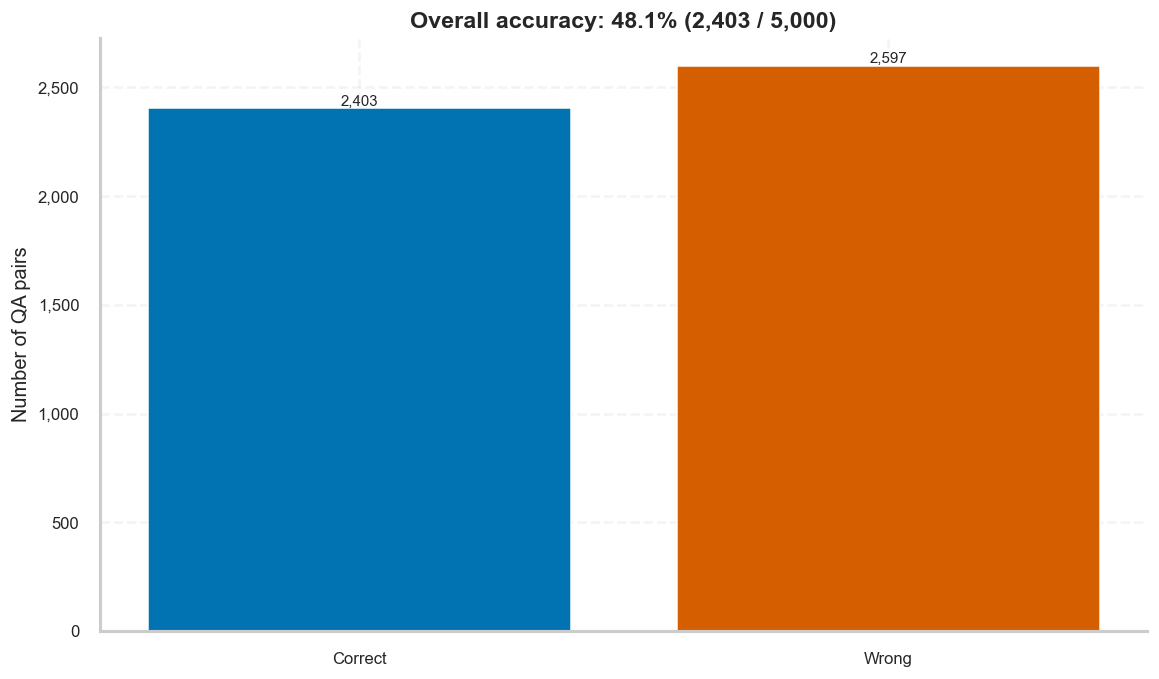

In [84]:
overall_acc = df['correct'].mean()
n_correct = df['correct'].sum()
n_total = len(df)

fig, ax = plt.subplots(figsize=PLOT_STYLE['figsize'])
bars = ax.bar(
    ['Correct', 'Wrong'],
    [n_correct, n_total - n_correct],
    color=[CORRECT_COLOR, WRONG_COLOR],
    edgecolor=PLOT_STYLE['bar_edgecolor'],
    linewidth=PLOT_STYLE['bar_linewidth']
)
ax.set_ylabel('Number of QA pairs', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title(f'Overall accuracy: {overall_acc:.1%} ({n_correct:,} / {n_total:,})',
             fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{int(h):,}', xy=(bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom',
                fontsize=PLOT_STYLE['annotation_fontsize'])
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 2. Accuracy by preference type

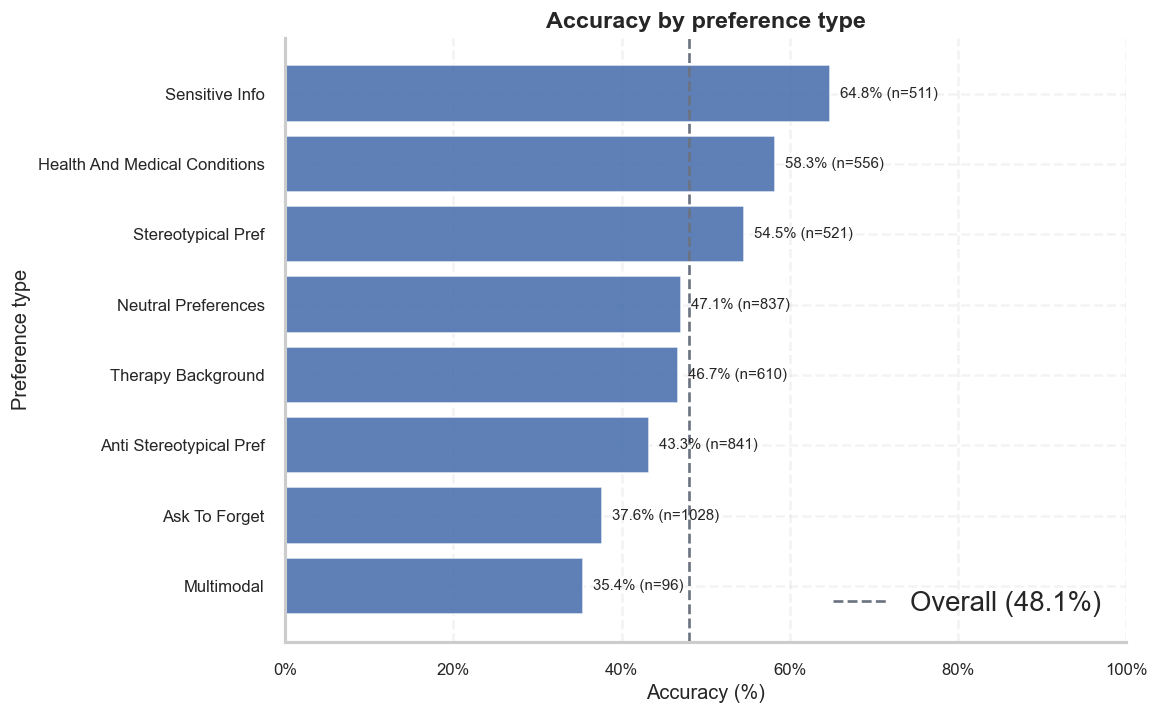

In [85]:
pref_stats = df.groupby('pref_type').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
pref_stats['accuracy'] = pref_stats['correct'] / pref_stats['total']
pref_stats['pref_label'] = pref_stats['pref_type'].str.replace('_', ' ').str.title()

plot_accuracy_breakdown(
    pref_stats,
    label_col='pref_label',
    title='Accuracy by preference type',
    y_label='Preference type',
    overall_acc=overall_acc,
)

## 3. Accuracy by preference type (counts and proportion)

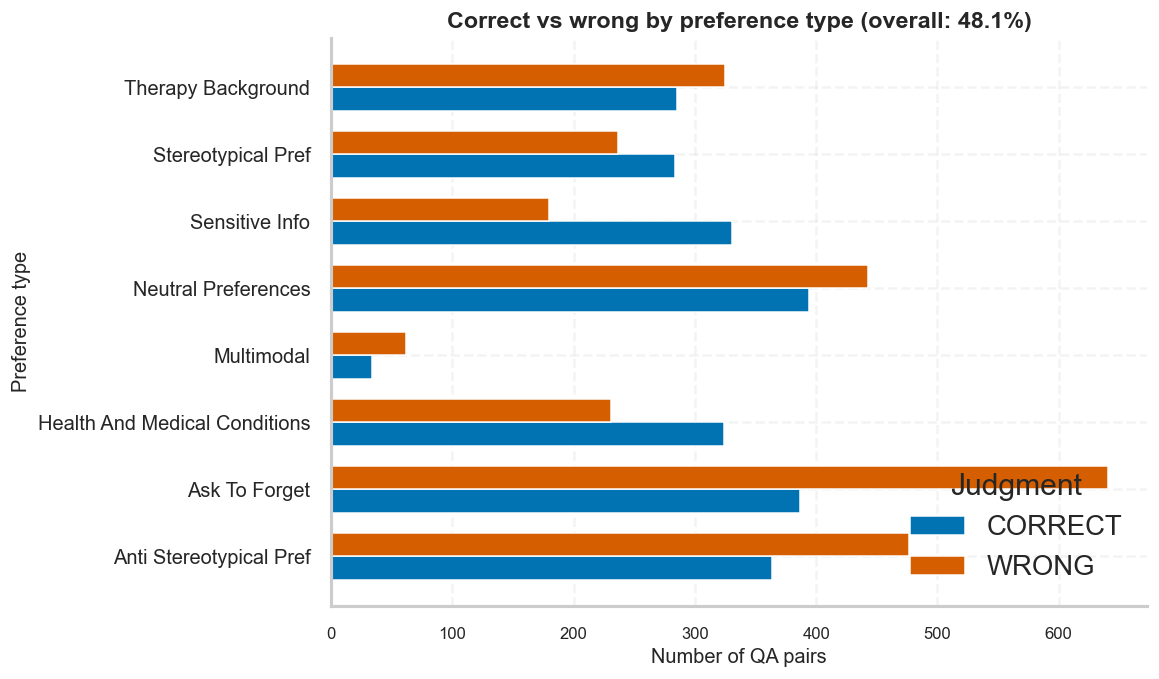

In [86]:
pref_long = df.groupby(['pref_type', 'is_correct']).size().reset_index(name='count')
pref_long['pref_label'] = pref_long['pref_type'].str.replace('_', ' ').str.title()

if 'pref_stats' not in globals():
    pref_stats = df.groupby('pref_type').agg(correct=('correct', 'sum'), total=('correct', 'count')).reset_index()
    pref_stats['accuracy'] = pref_stats['correct'] / pref_stats['total']
    pref_stats = pref_stats.sort_values('accuracy', ascending=True)
    pref_stats['pref_label'] = pref_stats['pref_type'].str.replace('_', ' ').str.title()

# Same order and style as other preference-type plots: horizontal bars, shared styling
order = pref_stats['pref_label'].tolist()
n = len(order)
y = np.arange(n)
bar_h = 0.35
counts_correct = [pref_long[(pref_long['pref_label'] == lbl) & (pref_long['is_correct'] == 'CORRECT')]['count'].sum() for lbl in order]
counts_wrong = [pref_long[(pref_long['pref_label'] == lbl) & (pref_long['is_correct'] == 'WRONG')]['count'].sum() for lbl in order]

fig, ax = plt.subplots(figsize=PLOT_STYLE['figsize'])
ax.barh(y - bar_h/2, counts_correct, height=bar_h, label='CORRECT', color=CORRECT_COLOR,
        edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
ax.barh(y + bar_h/2, counts_wrong, height=bar_h, label='WRONG', color=WRONG_COLOR,
        edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=PLOT_STYLE['label_fontsize'])
ax.set_xlabel('Number of QA pairs', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Preference type', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title(f'Correct vs wrong by preference type (overall: {overall_acc:.1%})',
             fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(title='Judgment', loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

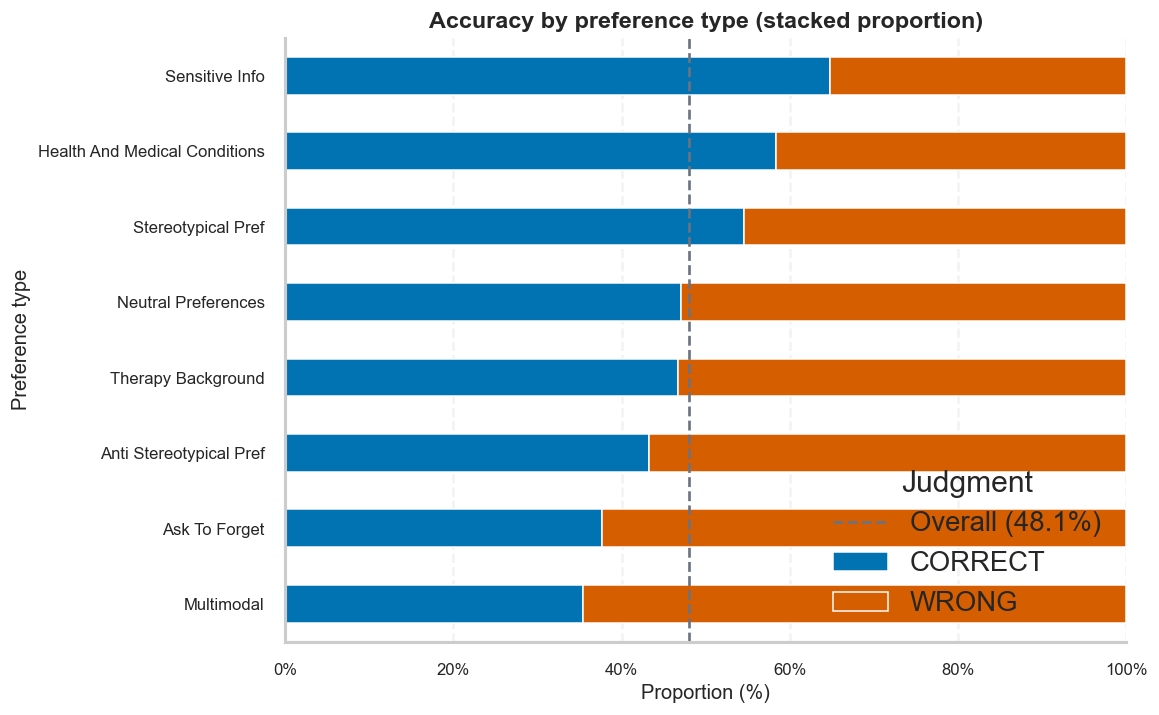

In [87]:
# Stacked bar: proportion correct vs wrong per preference type
if 'overall_acc' not in globals():
    overall_acc = df['correct'].mean()

pref_pivot = pref_long.pivot(index='pref_label', columns='is_correct', values='count').fillna(0)
for col in ['CORRECT', 'WRONG']:
    if col not in pref_pivot.columns:
        pref_pivot[col] = 0

pref_order = pref_stats.sort_values('accuracy', ascending=True)['pref_label'].tolist()
pref_pivot = pref_pivot.reindex(pref_order).fillna(0)
row_sums = pref_pivot.sum(axis=1)
pref_pct = pref_pivot.div(row_sums, axis=0).fillna(0)
pref_pct = pref_pct[[c for c in ['CORRECT', 'WRONG'] if c in pref_pct.columns]]

fig, ax = plt.subplots(figsize=(PLOT_STYLE['figsize'][0], _dynamic_height(len(pref_pct))))
pref_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[CORRECT_COLOR, WRONG_COLOR][:len(pref_pct.columns)],
    edgecolor=PLOT_STYLE['bar_edgecolor'],
    linewidth=PLOT_STYLE['bar_linewidth'],
)

ax.axvline(
    overall_acc,
    color=PLOT_STYLE['refline_color'],
    linestyle=PLOT_STYLE['refline_linestyle'],
    linewidth=PLOT_STYLE['refline_linewidth'],
    label=f'Overall ({overall_acc:.1%})',
)
ax.set_xlim(0, 1)
ax.set_xlabel('Proportion (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Preference type', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Accuracy by preference type (stacked proportion)',
             fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Judgment', loc='lower right')

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 4. Accuracy by conversation scenario

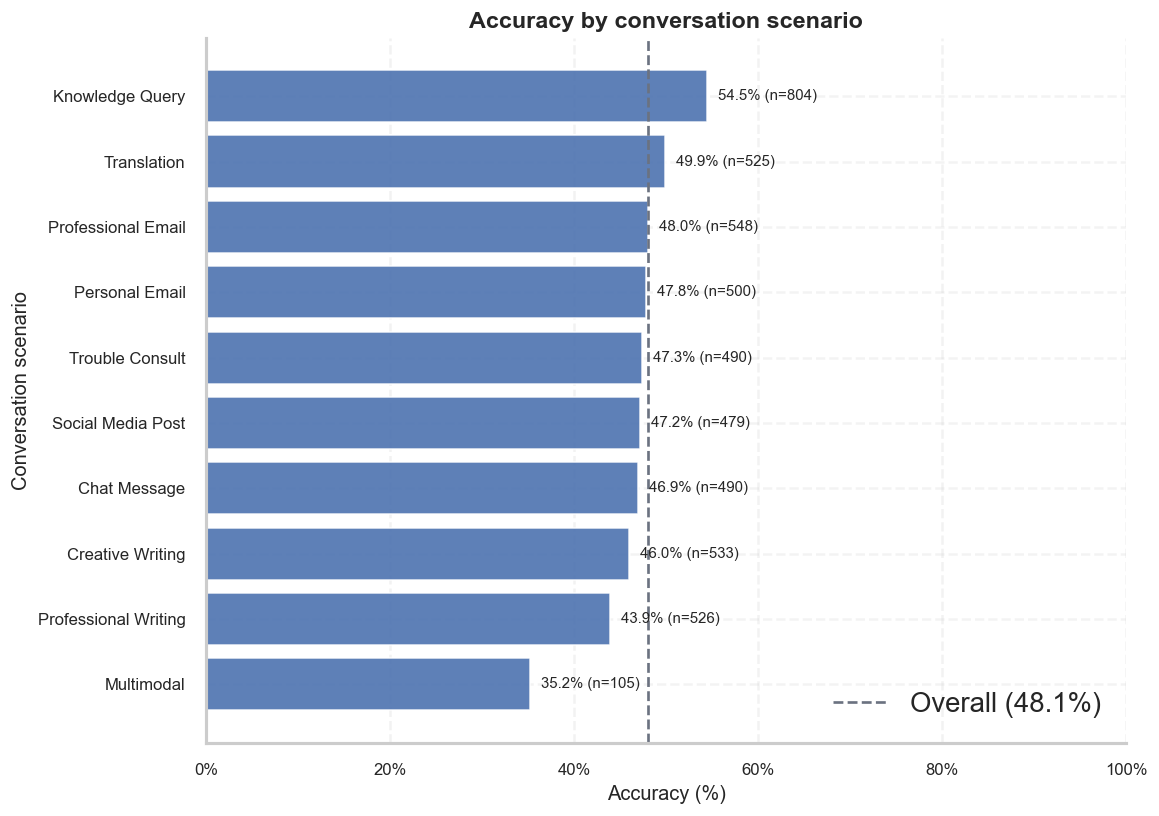

In [88]:
if 'overall_acc' not in globals():
    overall_acc = df['correct'].mean()

scenario_stats = df.groupby('conversation_scenario').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
scenario_stats['accuracy'] = scenario_stats['correct'] / scenario_stats['total']
scenario_stats['scenario_label'] = scenario_stats['conversation_scenario'].str.replace('_', ' ').str.title()

plot_accuracy_breakdown(
    scenario_stats,
    label_col='scenario_label',
    title='Accuracy by conversation scenario',
    y_label='Conversation scenario',
    overall_acc=overall_acc,
)


## 5. Accuracy by sensitive_info

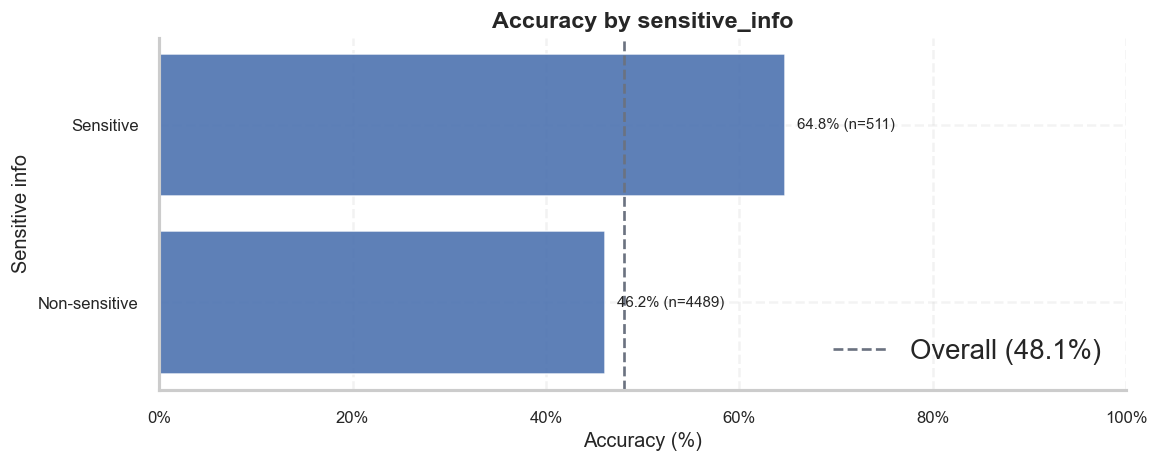

In [89]:
if 'overall_acc' not in globals():
    overall_acc = df['correct'].mean()

sens_stats = df.groupby('sensitive_info').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
sens_stats['accuracy'] = sens_stats['correct'] / sens_stats['total']
sens_stats['label'] = sens_stats['sensitive_info'].map({True: 'Sensitive', False: 'Non-sensitive'})

plot_accuracy_breakdown(
    sens_stats,
    label_col='label',
    title='Accuracy by sensitive_info',
    y_label='Sensitive info',
    overall_acc=overall_acc,
)

## 6. Accuracy by topic_query

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_9338/1403933023.py:24: UserWarning: Glyph 35013 (\N{CJK UNIFIED IDEOGRAPH-88C5}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_9338/1403933023.py:24: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/viktorzozula/MemoriesTesting/PersonaMem0/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35013 (\N{CJK UNIFIED IDEOGRAPH-88C5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/viktorzozula/MemoriesTesting/PersonaMem0/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


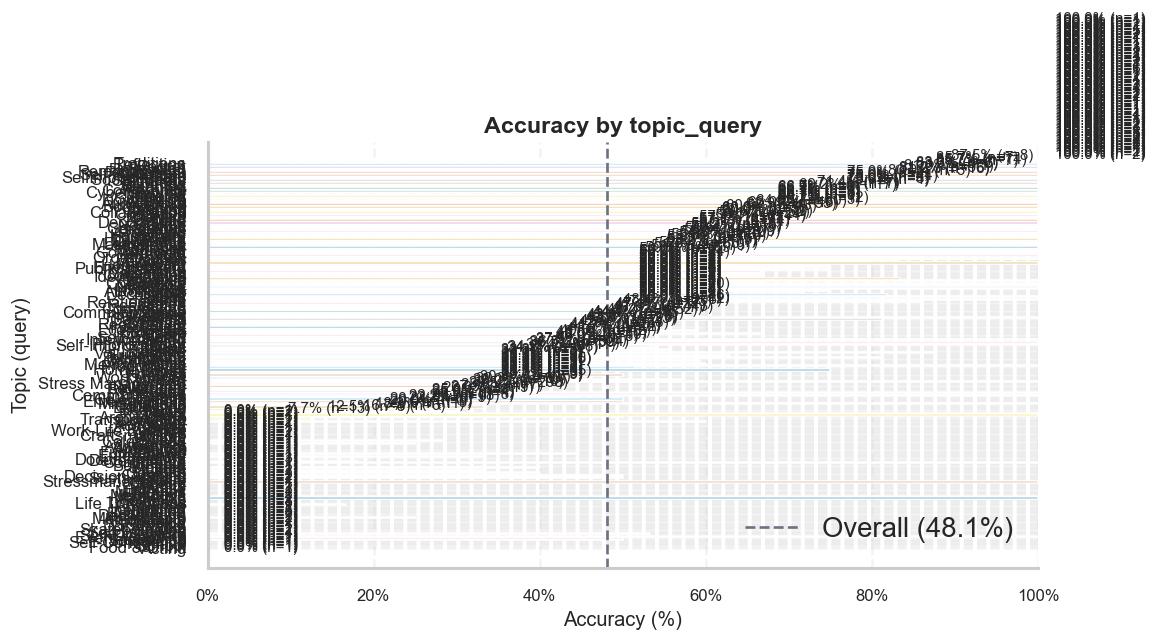

In [90]:
topic_query_stats = df.groupby('topic_query').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
topic_query_stats['accuracy'] = topic_query_stats['correct'] / topic_query_stats['total']
topic_query_stats = topic_query_stats.sort_values('accuracy', ascending=True)
topic_query_stats['label'] = topic_query_stats['topic_query'].astype(str).str.replace('_', ' ').str.title()

fig, ax = plt.subplots(figsize=PLOT_STYLE['figsize'])
colors = sns.color_palette('colorblind', n_colors=len(topic_query_stats))
bars = ax.barh(topic_query_stats['label'], topic_query_stats['accuracy'], color=colors,
               edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
ax.axvline(overall_acc, color=PLOT_STYLE['refline_color'], linestyle=PLOT_STYLE['refline_linestyle'],
           linewidth=PLOT_STYLE['refline_linewidth'], label=f'Overall ({overall_acc:.1%})')
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Topic (query)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Accuracy by topic_query', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
for i, (acc, n) in enumerate(zip(topic_query_stats['accuracy'], topic_query_stats['total'])):
    ax.text(acc + 0.02, i, f'{acc:.1%} (n={n})', va='center', fontsize=PLOT_STYLE['annotation_fontsize'])
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 7. Accuracy by topic_preference

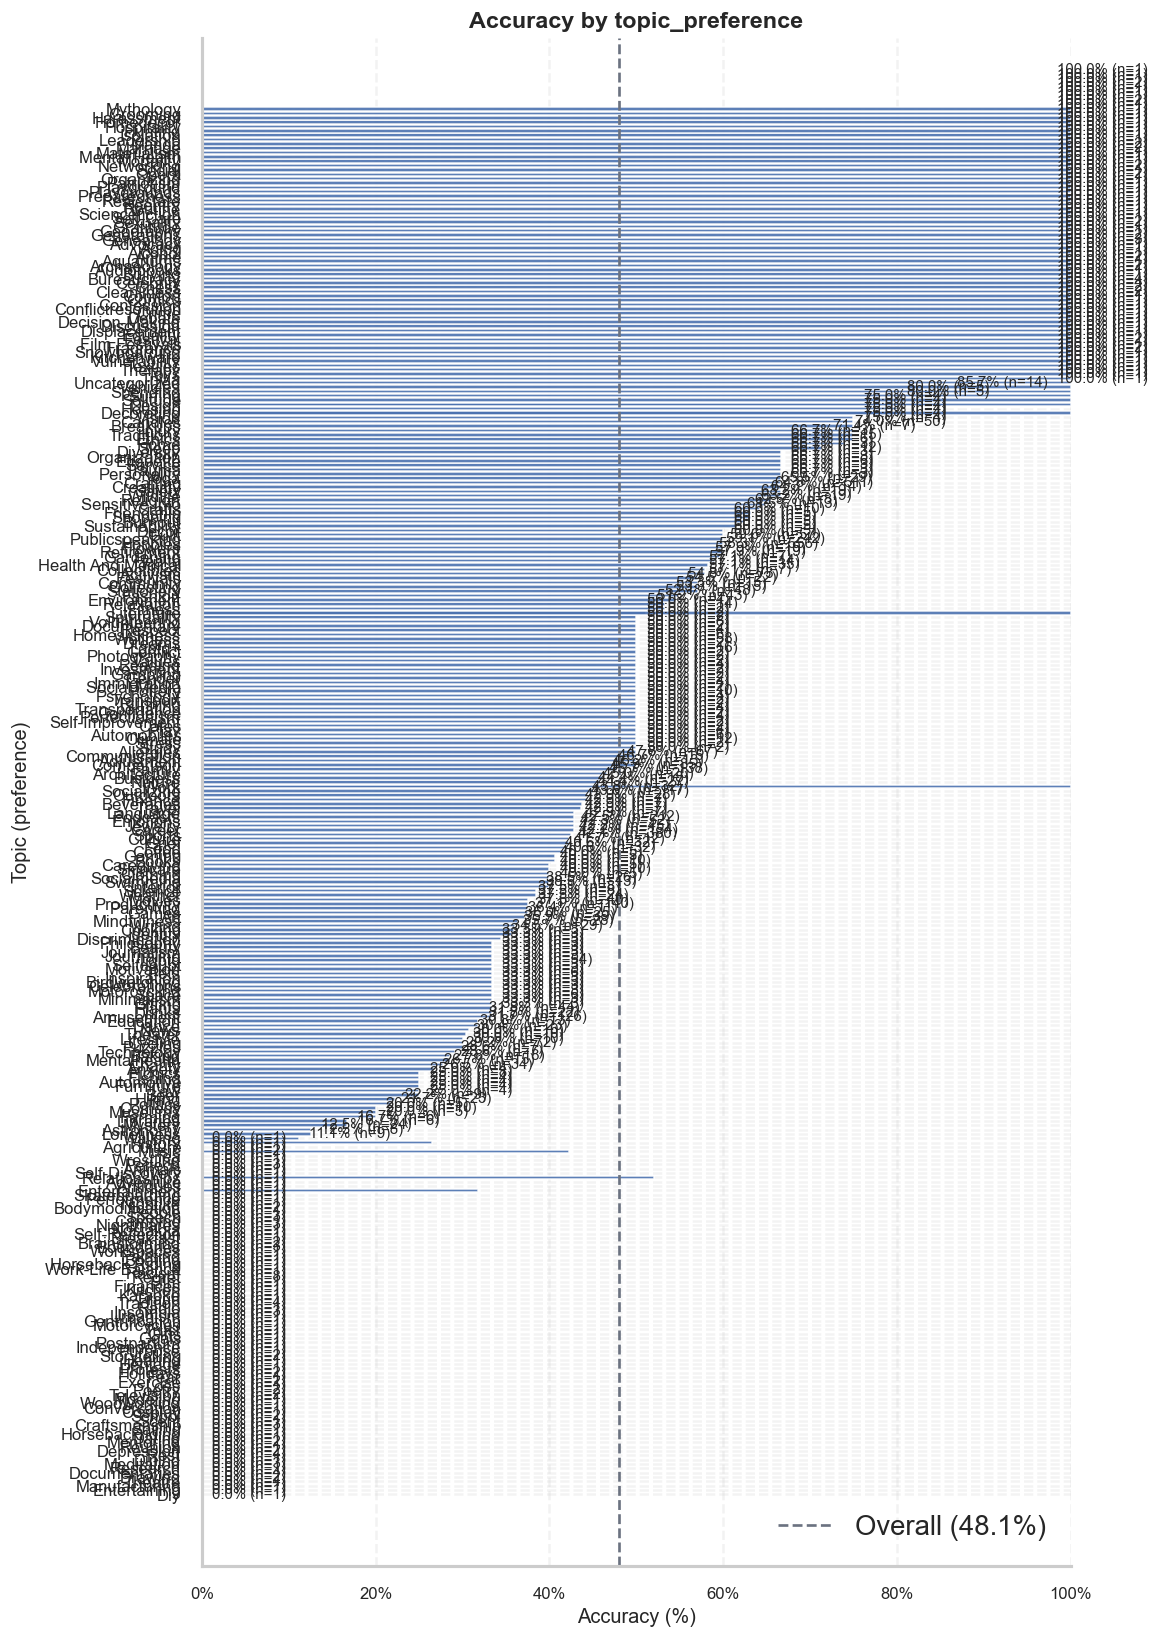

In [91]:
topic_pref_stats = df.groupby('topic_preference').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
topic_pref_stats['accuracy'] = topic_pref_stats['correct'] / topic_pref_stats['total']
topic_pref_stats['label'] = topic_pref_stats['topic_preference'].astype(str).str.replace('_', ' ').str.title()

plot_accuracy_breakdown(
    topic_pref_stats,
    label_col='label',
    title='Accuracy by topic_preference',
    y_label='Topic (preference)',
    overall_acc=overall_acc,
)

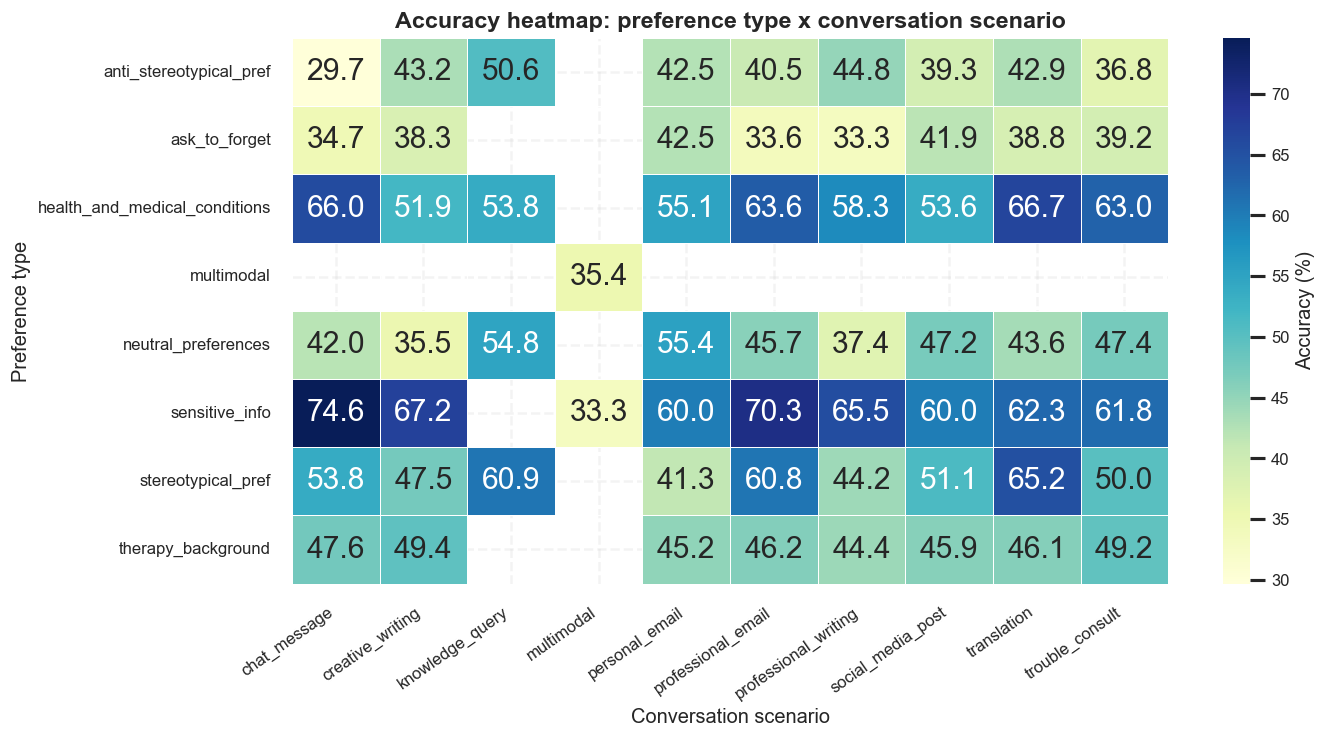

In [92]:
heat = df.pivot_table(
    index='pref_type',
    columns='conversation_scenario',
    values='correct',
    aggfunc='mean'
)
heat = heat.sort_index(axis=0).sort_index(axis=1)
heat_plot = (heat * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(
    heat_plot,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Accuracy (%)'},
    ax=ax
)
ax.set_title('Accuracy heatmap: preference type x conversation scenario', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.set_xlabel('Conversation scenario', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Preference type', fontsize=PLOT_STYLE['label_fontsize'])
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

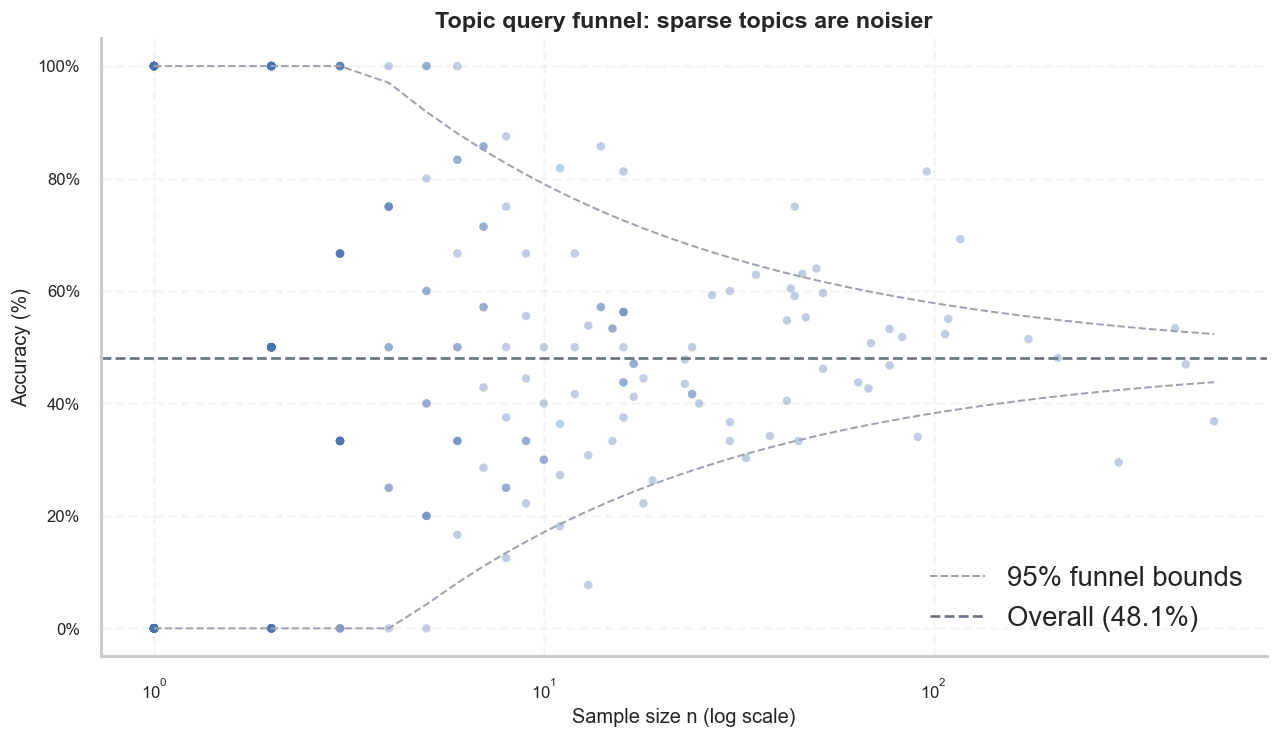

In [93]:
topic_q = df.groupby('topic_query').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
topic_q['accuracy'] = topic_q['correct'] / topic_q['total']

overall = df['correct'].mean()
x = np.arange(1, max(int(topic_q['total'].max()), 2) + 1)
se = np.sqrt(overall * (1 - overall) / x)
upper = np.clip(overall + 1.96 * se, 0, 1)
lower = np.clip(overall - 1.96 * se, 0, 1)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(topic_q['total'], topic_q['accuracy'], alpha=0.35, s=26, color=SINGLE_BAR_COLOR, edgecolor='none')
ax.plot(x, upper, linestyle='--', linewidth=1.2, color='#9CA3AF', label='95% funnel bounds')
ax.plot(x, lower, linestyle='--', linewidth=1.2, color='#9CA3AF')
ax.axhline(overall, color=PLOT_STYLE['refline_color'], linestyle=PLOT_STYLE['refline_linestyle'], linewidth=PLOT_STYLE['refline_linewidth'], label=f'Overall ({overall:.1%})')
ax.set_xscale('log')
ax.set_xlabel('Sample size n (log scale)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Topic query funnel: sparse topics are noisier', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='both', alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

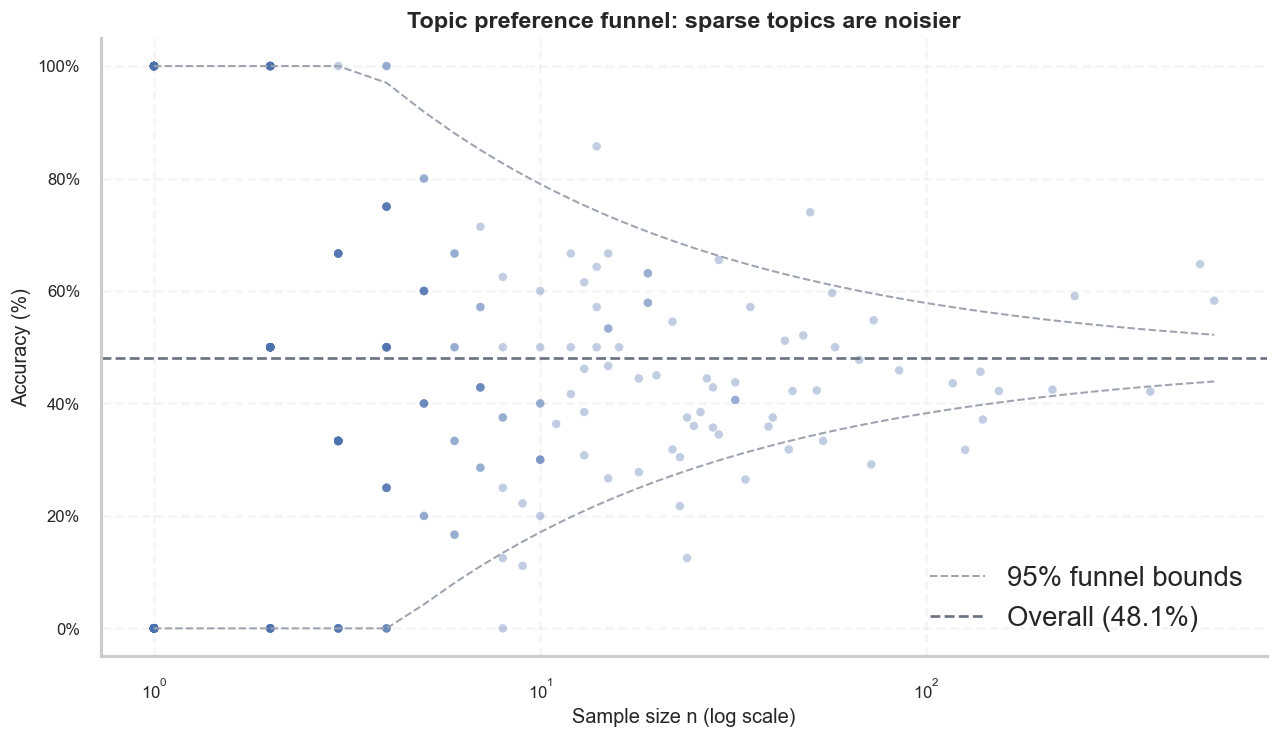

In [94]:
topic_p = df.groupby('topic_preference').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
topic_p['accuracy'] = topic_p['correct'] / topic_p['total']

overall = df['correct'].mean()
x = np.arange(1, max(int(topic_p['total'].max()), 2) + 1)
se = np.sqrt(overall * (1 - overall) / x)
upper = np.clip(overall + 1.96 * se, 0, 1)
lower = np.clip(overall - 1.96 * se, 0, 1)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(topic_p['total'], topic_p['accuracy'], alpha=0.35, s=26, color=SINGLE_BAR_COLOR, edgecolor='none')
ax.plot(x, upper, linestyle='--', linewidth=1.2, color='#9CA3AF', label='95% funnel bounds')
ax.plot(x, lower, linestyle='--', linewidth=1.2, color='#9CA3AF')
ax.axhline(overall, color=PLOT_STYLE['refline_color'], linestyle=PLOT_STYLE['refline_linestyle'], linewidth=PLOT_STYLE['refline_linewidth'], label=f'Overall ({overall:.1%})')
ax.set_xscale('log')
ax.set_xlabel('Sample size n (log scale)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Topic preference funnel: sparse topics are noisier', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='both', alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

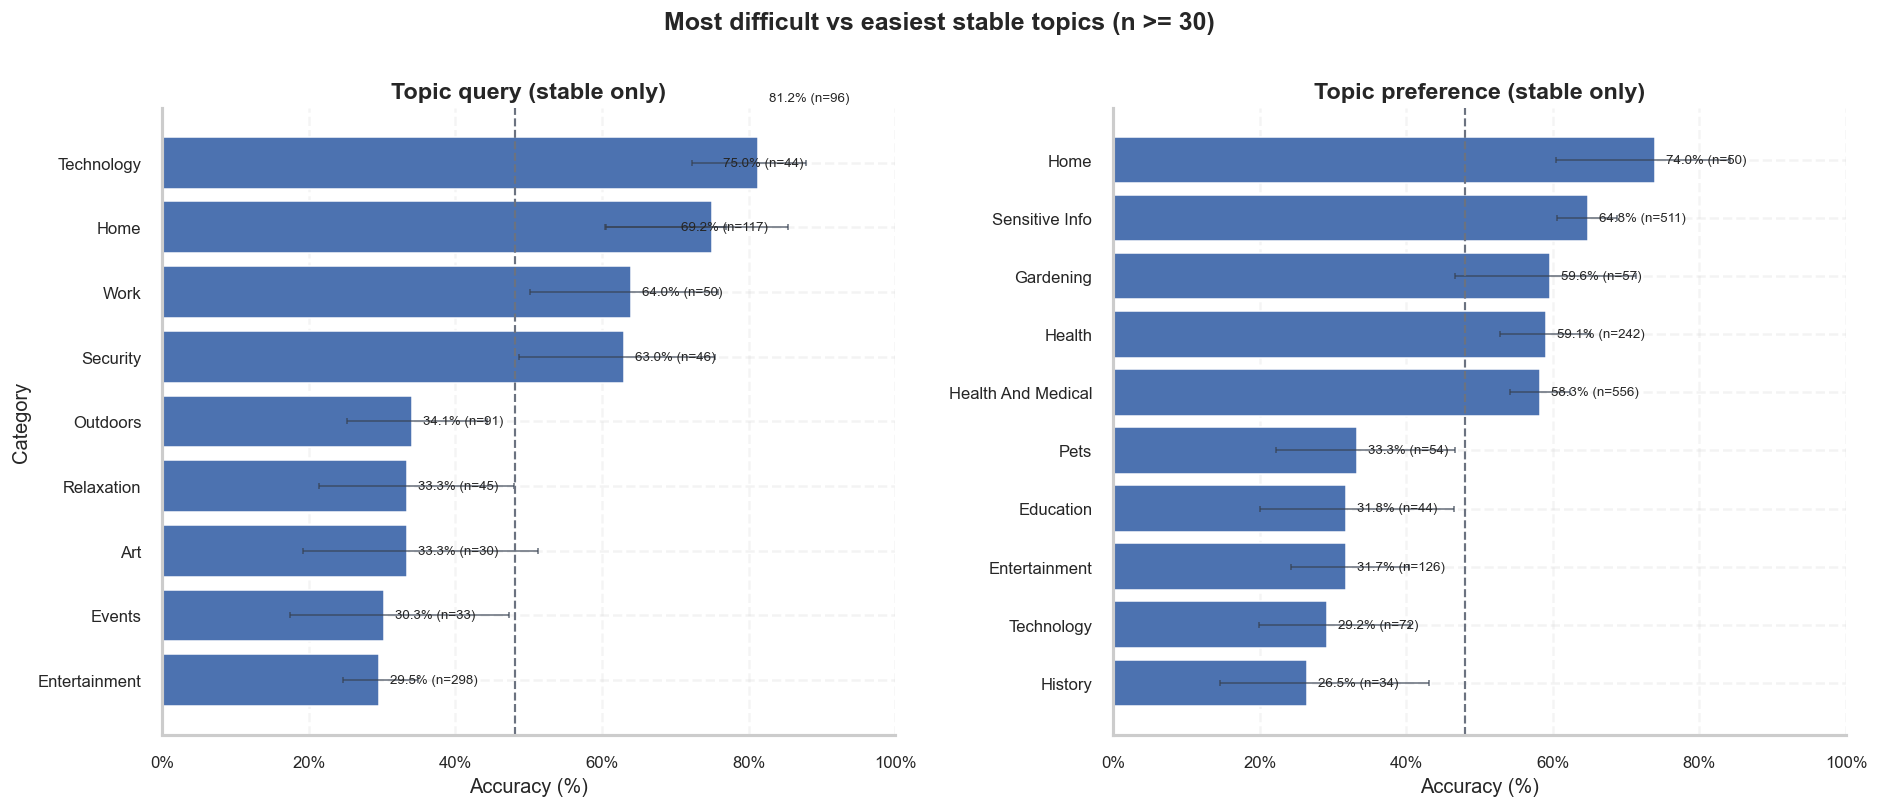

In [95]:
MIN_N = 30
K = 5

def top_bottom_stable(df_in, group_col, min_n=MIN_N, k=K):
    g = df_in.groupby(group_col).agg(correct=('correct', 'sum'), total=('correct', 'count')).reset_index()
    g = g[g['total'] >= min_n].copy()
    g['accuracy'] = g['correct'] / g['total']
    g['label'] = g[group_col].astype(str).str.replace('_', ' ').str.title()
    g = add_ci_columns(g)
    bottom = g.nsmallest(k, 'accuracy')
    top = g.nlargest(k, 'accuracy')
    out = pd.concat([bottom, top], axis=0).sort_values('accuracy')
    return out

q_tb = top_bottom_stable(df, 'topic_query')
p_tb = top_bottom_stable(df, 'topic_preference')

fig, axes = plt.subplots(1, 2, figsize=(16, _dynamic_height(max(len(q_tb), len(p_tb)), base=4.5, step=0.35, cap=10)), sharex=True)

for ax, g, title in [
    (axes[0], q_tb, 'Topic query (stable only)'),
    (axes[1], p_tb, 'Topic preference (stable only)')
]:
    ax.barh(g['label'], g['accuracy'], color=SINGLE_BAR_COLOR, edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
    # Wilson CI whiskers
    xerr = np.vstack([g['accuracy'] - g['ci_low'], g['ci_high'] - g['accuracy']])
    ax.errorbar(g['accuracy'], g['label'], xerr=xerr, fmt='none', ecolor='#374151', alpha=0.7, capsize=2, linewidth=1)
    ax.axvline(df['correct'].mean(), color=PLOT_STYLE['refline_color'], linestyle='--', linewidth=1.3)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
    ax.grid(axis='x', alpha=0.2)
    for i, (acc, n) in enumerate(zip(g['accuracy'], g['total'])):
        ax.text(min(acc + 0.015, 0.98), i, f'{acc:.1%} (n={n})', va='center', fontsize=8)
    sns.despine(ax=ax)

axes[0].set_ylabel('Category', fontsize=PLOT_STYLE['label_fontsize'])
axes[1].set_ylabel('')
for ax in axes:
    ax.set_xlabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])

fig.suptitle('Most difficult vs easiest stable topics (n >= 30)', fontsize=PLOT_STYLE['title_fontsize'] + 1, fontweight='bold')
plt.tight_layout()
plt.show()

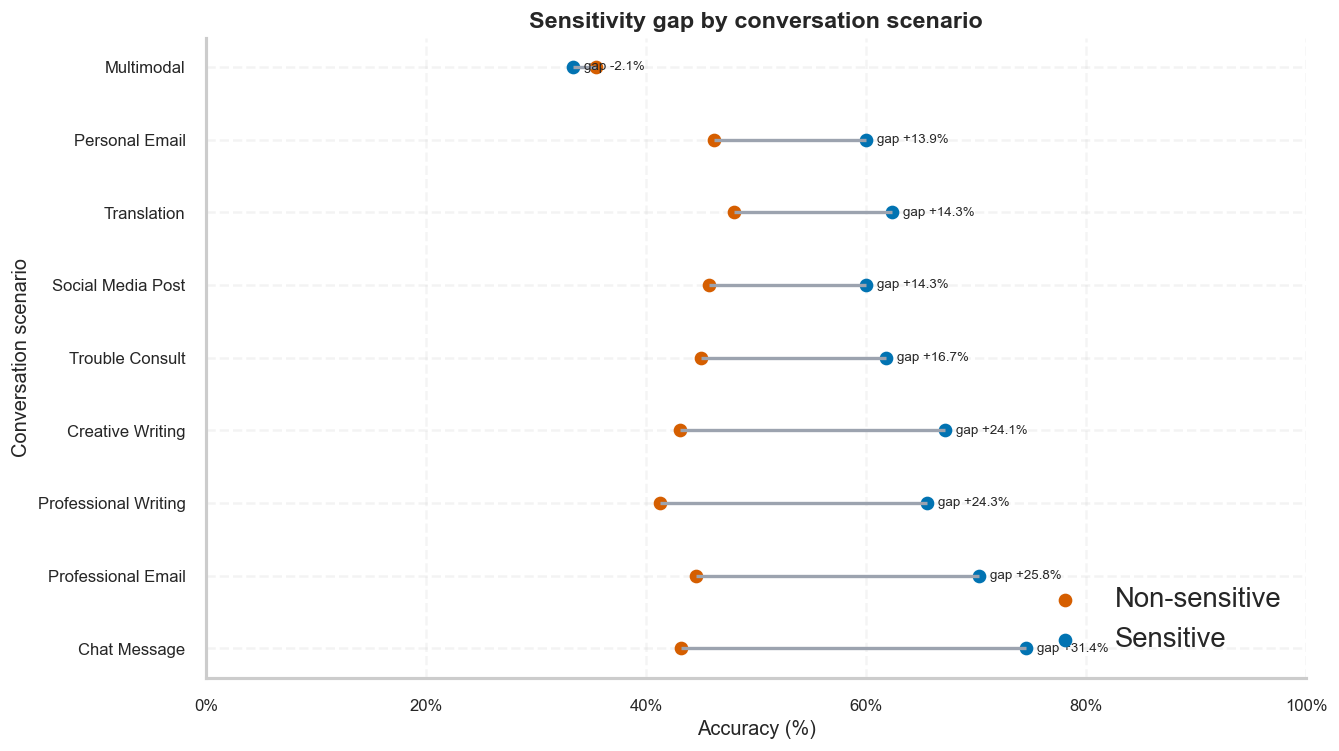

In [96]:
gap = df.groupby(['conversation_scenario', 'sensitive_info']).agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
gap['accuracy'] = gap['correct'] / gap['total']

pivot = gap.pivot(index='conversation_scenario', columns='sensitive_info', values='accuracy')
pivot = pivot.rename(columns={False: 'Non-sensitive', True: 'Sensitive'})
pivot = pivot.dropna().copy()
pivot['gap'] = pivot['Sensitive'] - pivot['Non-sensitive']
pivot = pivot.sort_values('gap', ascending=False)

labels = pivot.index.str.replace('_', ' ').str.title()
y = np.arange(len(pivot))

fig, ax = plt.subplots(figsize=(11.5, _dynamic_height(len(pivot), base=4.5, step=0.35, cap=10)))
ax.hlines(y=y, xmin=pivot['Non-sensitive'], xmax=pivot['Sensitive'], color='#9CA3AF', linewidth=2)
ax.scatter(pivot['Non-sensitive'], y, color=WRONG_COLOR, s=45, label='Non-sensitive')
ax.scatter(pivot['Sensitive'], y, color=CORRECT_COLOR, s=45, label='Sensitive')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Conversation scenario', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Sensitivity gap by conversation scenario', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.2)
for i, g in enumerate(pivot['gap']):
    ax.text(min(pivot['Sensitive'].iloc[i] + 0.01, 0.98), i, f'gap {g:+.1%}', va='center', fontsize=8)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

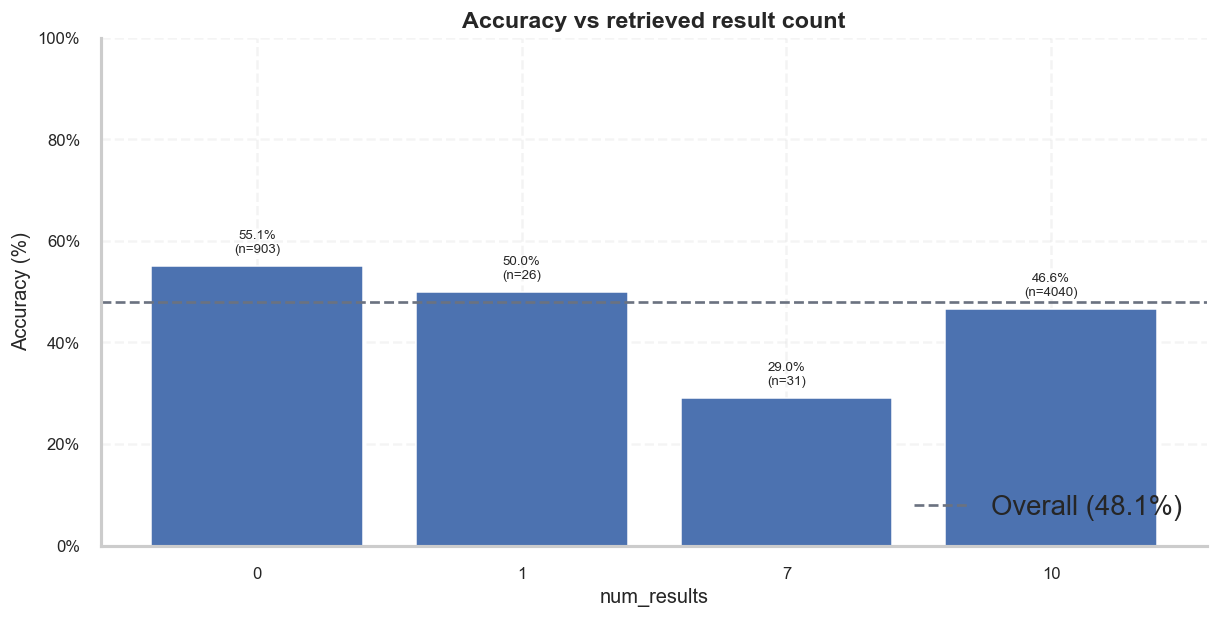

In [97]:
nr = df.groupby('num_results').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
nr['accuracy'] = nr['correct'] / nr['total']
nr = nr.sort_values('num_results')

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.bar(nr['num_results'].astype(str), nr['accuracy'], color=SINGLE_BAR_COLOR, edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
ax.axhline(df['correct'].mean(), color=PLOT_STYLE['refline_color'], linestyle='--', linewidth=PLOT_STYLE['refline_linewidth'], label=f'Overall ({df["correct"].mean():.1%})')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('num_results', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Accuracy vs retrieved result count', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
for i, (acc, n) in enumerate(zip(nr['accuracy'], nr['total'])):
    ax.text(i, min(acc + 0.02, 0.98), f'{acc:.1%}\n(n={n})', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

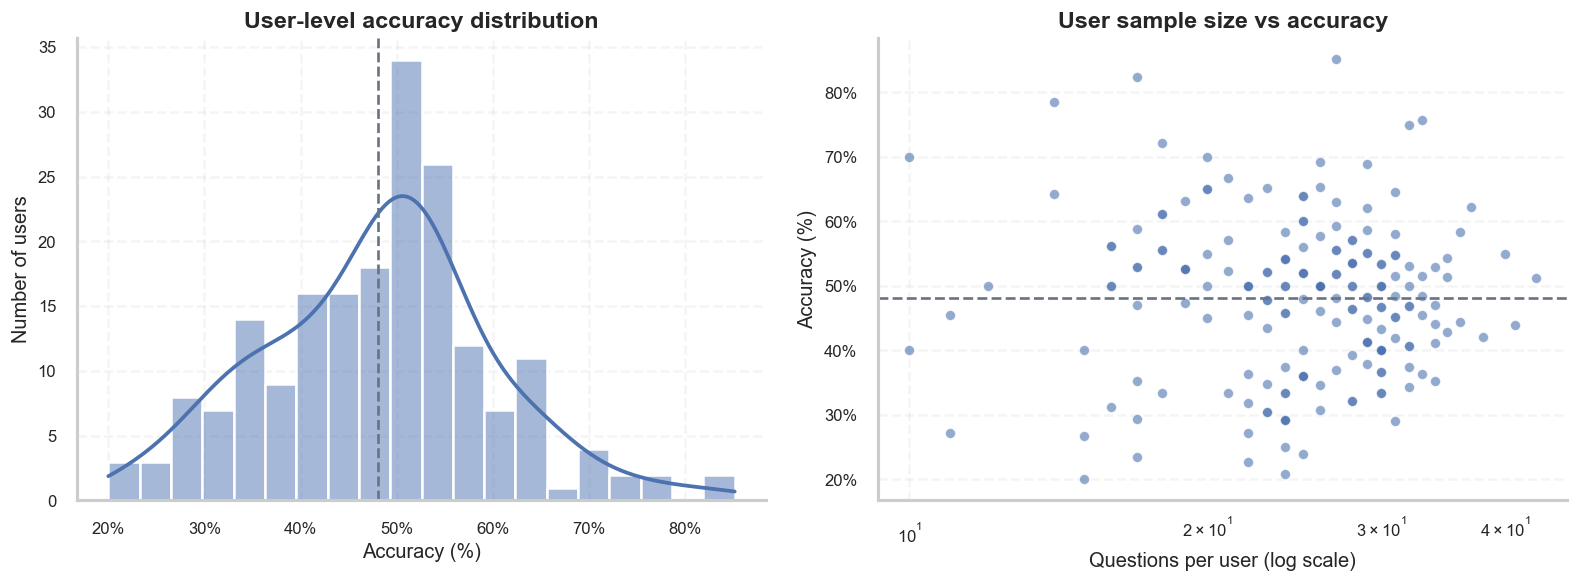

In [98]:
user_acc = df.groupby('user_id').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
user_acc['accuracy'] = user_acc['correct'] / user_acc['total']

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

sns.histplot(user_acc['accuracy'], bins=20, kde=True, color=SINGLE_BAR_COLOR, ax=axes[0])
axes[0].axvline(df['correct'].mean(), color=PLOT_STYLE['refline_color'], linestyle='--', linewidth=PLOT_STYLE['refline_linewidth'])
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('User-level accuracy distribution', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Number of users')

sns.scatterplot(data=user_acc, x='total', y='accuracy', alpha=0.6, s=35, color=SINGLE_BAR_COLOR, ax=axes[1])
axes[1].axhline(df['correct'].mean(), color=PLOT_STYLE['refline_color'], linestyle='--', linewidth=PLOT_STYLE['refline_linewidth'])
axes[1].set_xscale('log')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('User sample size vs accuracy', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
axes[1].set_xlabel('Questions per user (log scale)')
axes[1].set_ylabel('Accuracy (%)')

for ax in axes:
    ax.grid(alpha=0.2)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

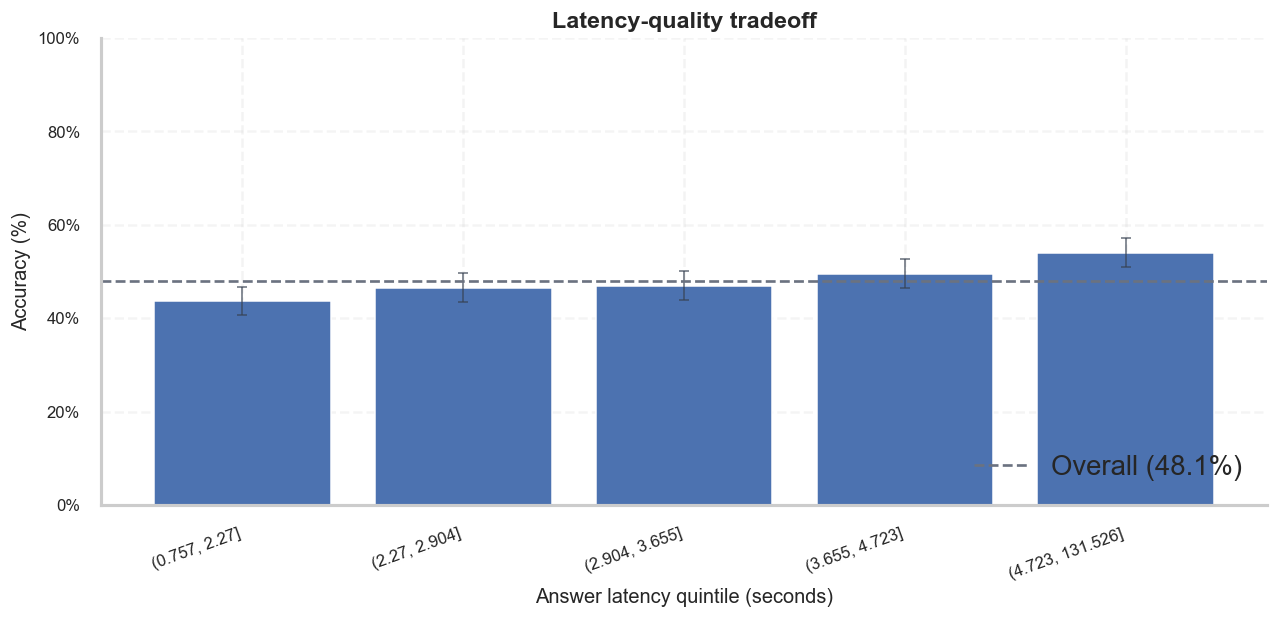

In [99]:
lat = df[['answer_wall_seconds', 'correct']].dropna().copy()
lat['latency_bin'] = pd.qcut(lat['answer_wall_seconds'], q=5, duplicates='drop')
lat_stats = lat.groupby('latency_bin', observed=False).agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
lat_stats['accuracy'] = lat_stats['correct'] / lat_stats['total']
lat_stats = add_ci_columns(lat_stats)
lat_stats['label'] = lat_stats['latency_bin'].astype(str)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(lat_stats['label'], lat_stats['accuracy'], color=SINGLE_BAR_COLOR, edgecolor=PLOT_STYLE['bar_edgecolor'], linewidth=PLOT_STYLE['bar_linewidth'])
# error bars from Wilson CI
xerr = np.vstack([lat_stats['accuracy'] - lat_stats['ci_low'], lat_stats['ci_high'] - lat_stats['accuracy']])
ax.errorbar(np.arange(len(lat_stats)), lat_stats['accuracy'], yerr=xerr, fmt='none', ecolor='#374151', alpha=0.7, capsize=3, linewidth=1)
ax.axhline(df['correct'].mean(), color=PLOT_STYLE['refline_color'], linestyle=PLOT_STYLE['refline_linestyle'], linewidth=PLOT_STYLE['refline_linewidth'], label=f'Overall ({df["correct"].mean():.1%})')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Answer latency quintile (seconds)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_ylabel('Accuracy (%)', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Latency-quality tradeoff', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
ax.grid(axis='y', alpha=0.2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 8. Multimodality coverage and image counts

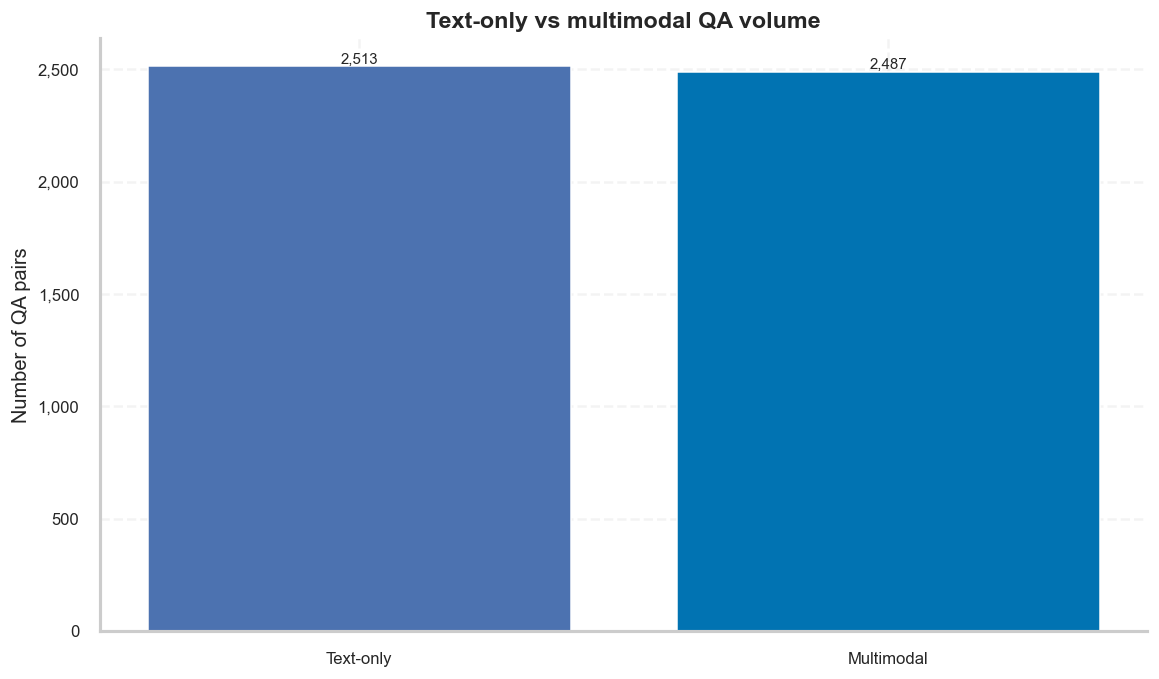

In [100]:
total_qas = len(df)
multimodal_qas = int(df['has_image'].sum())
text_only_qas = total_qas - multimodal_qas

images_from_per_qa = int(df['image_count'].sum())
reported_total_images = int(reported_total_images_processed) if reported_total_images_processed is not None else np.nan
users_with_images = df.loc[df['has_image'], 'user_id'].nunique() if 'user_id' in df.columns else np.nan

total_images_for_avg = reported_total_images if pd.notna(reported_total_images) else images_from_per_qa

mm_summary = pd.DataFrame({
    'metric': [
        'Total QA pairs',
        'Text-only QA pairs',
        'Multimodal QA pairs',
        'Multimodal share',
        'Total images (per-QA sum)',
        'Total images (run-level reported)',
        'Average images per multimodal QA',
        'Unique users with multimodal QA',
    ],
    'value': [
        total_qas,
        text_only_qas,
        multimodal_qas,
        multimodal_qas / total_qas if total_qas else np.nan,
        images_from_per_qa,
        reported_total_images,
        total_images_for_avg / multimodal_qas if multimodal_qas else np.nan,
        users_with_images,
    ]
})

mm_summary

fig, ax = plt.subplots(figsize=PLOT_STYLE['figsize'])
bars = ax.bar(
    ['Text-only', 'Multimodal'],
    [text_only_qas, multimodal_qas],
    color=[SINGLE_BAR_COLOR, CORRECT_COLOR],
    edgecolor=PLOT_STYLE['bar_edgecolor'],
    linewidth=PLOT_STYLE['bar_linewidth'],
)
ax.set_ylabel('Number of QA pairs', fontsize=PLOT_STYLE['label_fontsize'])
ax.set_title('Text-only vs multimodal QA volume', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{int(h):,}', xy=(bar.get_x() + bar.get_width() / 2, h), ha='center', va='bottom', fontsize=PLOT_STYLE['annotation_fontsize'])

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 9. Accuracy by modality (text-only vs multimodal)

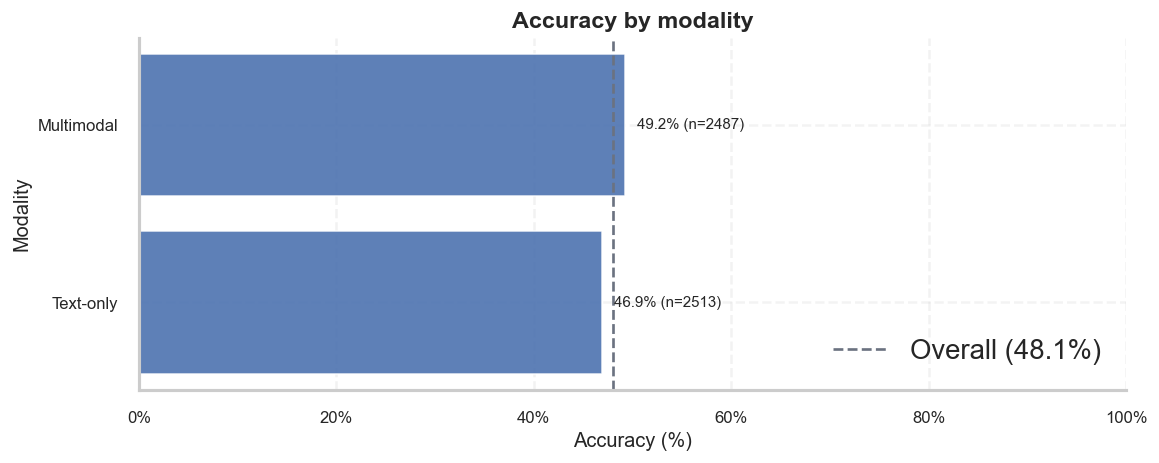

,modality,correct,total,accuracy
0,Multimodal,1224,2487,0.492159
1,Text-only,1179,2513,0.469160


In [101]:
modality_stats = df.groupby('modality').agg(
    correct=('correct', 'sum'),
    total=('correct', 'count')
).reset_index()
modality_stats['accuracy'] = modality_stats['correct'] / modality_stats['total']

plot_accuracy_breakdown(
    modality_stats,
    label_col='modality',
    title='Accuracy by modality',
    y_label='Modality',
    overall_acc=overall_acc
)

modality_stats.sort_values('accuracy', ascending=False)

## 10. Per-user image counts

,user_id,qa_total,multimodal_qas,image_count_per_qa,images_processed_reported,image_count_for_ranking,multimodal_share,accuracy
164,859,28,28,168,6,6,1.0,0.535714
60,310,20,20,120,6,6,1.0,0.650000
21,110,26,26,130,5,5,1.0,0.692308
5,44,18,18,90,5,5,1.0,0.555556
70,355,17,17,85,5,5,1.0,0.470588
14,72,34,34,136,4,4,1.0,0.470588
25,139,30,30,120,4,4,1.0,0.400000
177,917,30,30,120,4,4,1.0,0.500000
150,787,24,24,96,4,4,1.0,0.541667
153,810,20,20,80,4,4,1.0,0.550000


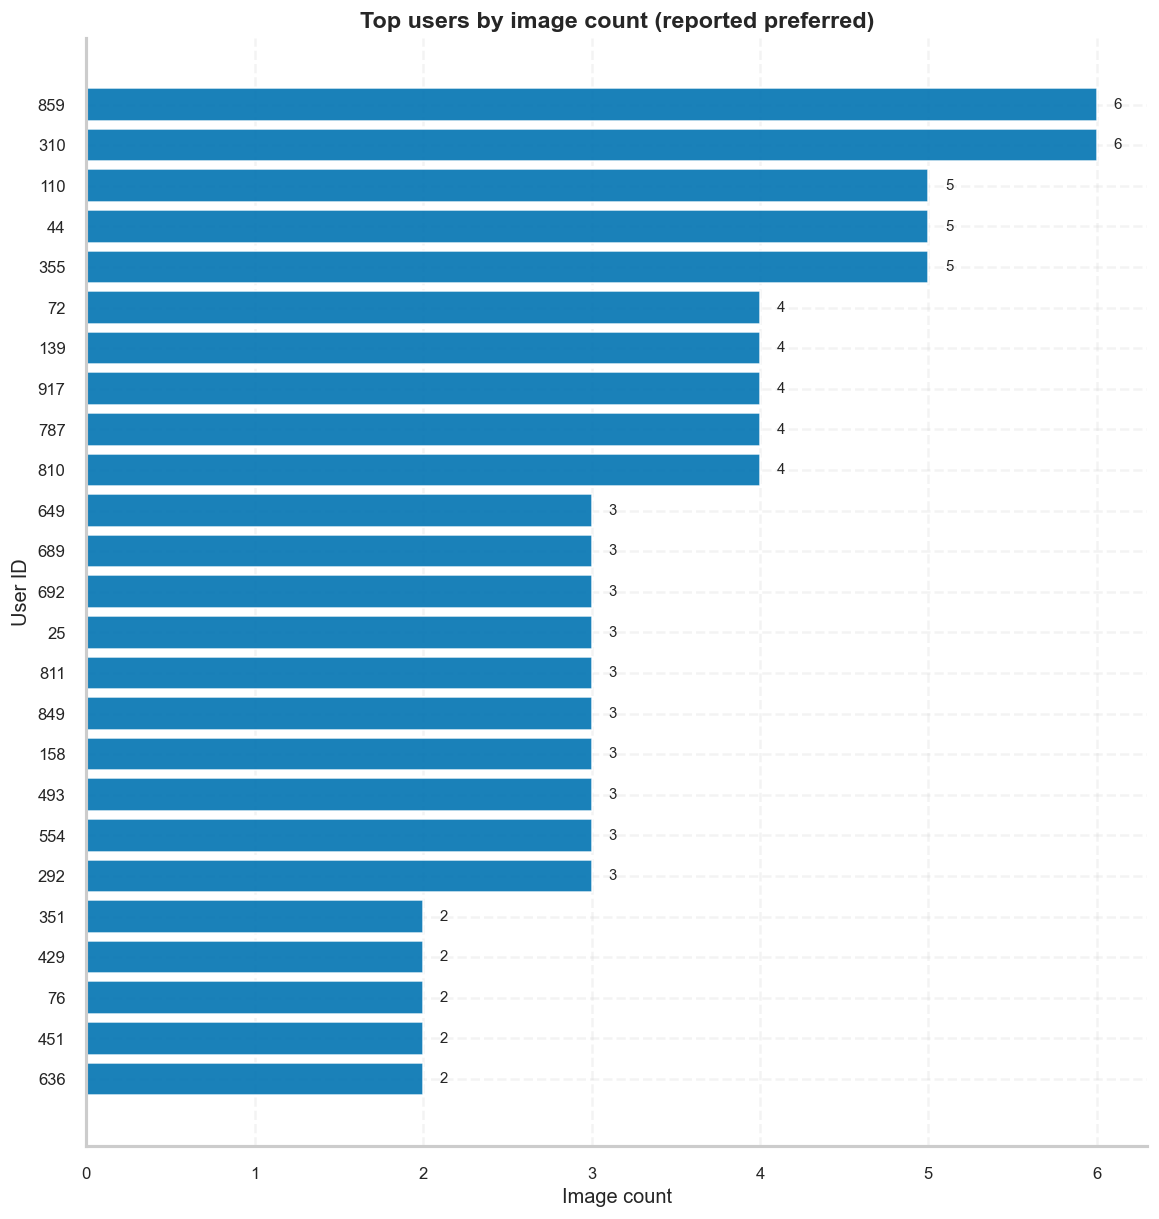

In [102]:
if 'user_id' in df.columns:
    user_mm = df.groupby('user_id').agg(
        qa_total=('correct', 'count'),
        multimodal_qas=('has_image', 'sum'),
        image_count_per_qa=('image_count', 'sum'),
        correct=('correct', 'sum')
    ).reset_index()

    user_mm['multimodal_share'] = user_mm['multimodal_qas'] / user_mm['qa_total']
    user_mm['accuracy'] = user_mm['correct'] / user_mm['qa_total']

    if not images_per_user_reported_df.empty:
        user_mm = user_mm.merge(images_per_user_reported_df, on='user_id', how='left')
    else:
        user_mm['images_processed_reported'] = np.nan

    user_mm['image_count_for_ranking'] = user_mm['images_processed_reported'].fillna(user_mm['image_count_per_qa'])
    user_mm_sorted = user_mm.sort_values(['image_count_for_ranking', 'multimodal_qas'], ascending=False)

    display_cols = [
        'user_id', 'qa_total', 'multimodal_qas', 'image_count_per_qa',
        'images_processed_reported', 'image_count_for_ranking',
        'multimodal_share', 'accuracy'
    ]
    display(user_mm_sorted[display_cols].head(20))

    top_n = min(25, len(user_mm_sorted))
    top_users = user_mm_sorted.head(top_n).sort_values('image_count_for_ranking', ascending=True)

    fig, ax = plt.subplots(figsize=(PLOT_STYLE['figsize'][0], _dynamic_height(top_n, base=5.0, step=0.25, cap=14)))
    bars = ax.barh(
        top_users['user_id'].astype(str),
        top_users['image_count_for_ranking'],
        color=CORRECT_COLOR,
        alpha=0.9,
        edgecolor=PLOT_STYLE['bar_edgecolor'],
        linewidth=PLOT_STYLE['bar_linewidth'],
    )

    ax.set_xlabel('Image count', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_ylabel('User ID', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_title('Top users by image count (reported preferred)', fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold')

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height() / 2, f'{int(w)}', va='center', fontsize=PLOT_STYLE['annotation_fontsize'])

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'user_id' not found in dataset.")